In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd 
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def tradingview_scraper():
    urls = [
        'https://www.tradingview.com/markets/stocks-indonesia/market-movers-52wk-high',
        'https://www.tradingview.com/markets/stocks-indonesia/market-movers-gainers'
    ]

    results = {}  # store all scraped DataFrames

    for url in urls:
        try:
            print(f"Scraping data from: {url}")

            # Fetch HTML content
            response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
            response.raise_for_status()  
            soup = BeautifulSoup(response.text, "html.parser")

            # Extract table element
            table = soup.find("table")
            if table is None:
                print("No table found on this page.")
                continue

            # Extract headers
            headers = [header.text.strip() for header in table.find_all("th")]

            # Extract table rows
            rows = []
            for tr in table.find_all("tr")[1:]:
                cells = [td.text.strip() for td in tr.find_all("td")]
                if cells:
                    rows.append(cells)

            # Convert to DataFrame
            df = pd.DataFrame(rows, columns=headers)

            # Get label from URL
            category = url.split("market-movers-")[1]
            results[category] = df

            # Display preview
            print(f"{category} scraped successfully ({len(df)} rows)")
            print(df.head(10))

        except requests.exceptions.RequestException as err:
            print(f"Request error while accessing {url}: {err}")
        except Exception as e:
            print(f"Unexpected error while processing {url}: {e}")

    return results

data_dict = tradingview_scraper()


Scraping data from: https://www.tradingview.com/markets/stocks-indonesia/market-movers-52wk-high
52wk-high scraped successfully (27 rows)
                               Symbol      Price Change %    Volume  \
0          ARCIPT Archi Indonesia Tbk  1,435 IDR   −2.71%  438.55 M   
1   BAJAPT Saranacentral Bajatama Tbk    180 IDR  +13.21%  181.17 M   
2       BHATPT Bhakti Multi Artha Tbk    930 IDR    0.00%    1.93 M   
3     BLUEPT Berkah Prima Perkasa Tbk  1,315 IDR  +24.64%   771.9 K   
4  BWPTPT Eagle High Plantations Tbk.    151 IDR  −14.69%    1.35 B   
5                  CTTHPT Citatah Tbk     82 IDR   +9.33%   41.38 M   
6             DATAPT Remala Abadi Tbk  6,000 IDR   −6.25%   12.48 M   
7  EEMASPT Merdeka Gold Resources Tbk  4,830 IDR   +6.86%  133.78 M   
8       ESTIPT Ever Shine Textile Tbk    150 IDR   +6.38%    6.24 M   
9          EUROPT Estee Gold Feet Tbk    536 IDR   +9.63%     8.4 K   

  Rel Volume    Market cap     P/E  EPS dilTTM EPS dil growthTTM YoY  \
0       

In [3]:
df_high = data_dict['52wk-high']
df_high.head()

,Symbol,Price,Change %,Volume,Rel Volume,Market cap,P/E,EPS dilTTM,EPS dil growthTTM YoY,Div yield %TTM,Sector,Analyst Rating
0,ARCIPT Archi Indonesia Tbk,"1,435 IDR",−2.71%,438.55 M,1.53,36.63 T IDR,44.59,32.18 IDR,"+1,413.87%",0.00%,Non-energy minerals,Strong buy
1,BAJAPT Saranacentral Bajatama Tbk,180 IDR,+13.21%,181.17 M,13.43,286.2 B IDR,—,−13.12 IDR,+58.31%,0.00%,Non-energy minerals,Neutral
2,BHATPT Bhakti Multi Artha Tbk,930 IDR,0.00%,1.93 M,0.93,4.65 T IDR,—,−0.56 IDR,−146.37%,0.00%,Commercial services,Neutral
3,BLUEPT Berkah Prima Perkasa Tbk,"1,315 IDR",+24.64%,771.9 K,0.31,440.99 B IDR,37.29,35.26 IDR,+7.79%,2.18%,Distribution services,Neutral
4,BWPTPT Eagle High Plantations Tbk.,151 IDR,−14.69%,1.35 B,2.18,5.58 T IDR,15.04,10.04 IDR,+40.10%,0.00%,Process industries,Neutral


In [4]:
df_high

,Symbol,Price,Change %,Volume,Rel Volume,Market cap,P/E,EPS dilTTM,EPS dil growthTTM YoY,Div yield %TTM,Sector,Analyst Rating
0,ARCIPT Archi Indonesia Tbk,"1,435 IDR",−2.71%,438.55 M,1.53,36.63 T IDR,44.59,32.18 IDR,"+1,413.87%",0.00%,Non-energy minerals,Strong buy
1,BAJAPT Saranacentral Bajatama Tbk,180 IDR,+13.21%,181.17 M,13.43,286.2 B IDR,—,−13.12 IDR,+58.31%,0.00%,Non-energy minerals,Neutral
2,BHATPT Bhakti Multi Artha Tbk,930 IDR,0.00%,1.93 M,0.93,4.65 T IDR,—,−0.56 IDR,−146.37%,0.00%,Commercial services,Neutral
3,BLUEPT Berkah Prima Perkasa Tbk,"1,315 IDR",+24.64%,771.9 K,0.31,440.99 B IDR,37.29,35.26 IDR,+7.79%,2.18%,Distribution services,Neutral
4,BWPTPT Eagle High Plantations Tbk.,151 IDR,−14.69%,1.35 B,2.18,5.58 T IDR,15.04,10.04 IDR,+40.10%,0.00%,Process industries,Neutral
5,CTTHPT Citatah Tbk,82 IDR,+9.33%,41.38 M,11.08,92.31 B IDR,—,−20.31 IDR,−135.36%,0.00%,Non-energy minerals,Neutral
6,DATAPT Remala Abadi Tbk,"6,000 IDR",−6.25%,12.48 M,0.99,8.8 T IDR,83.68,71.70 IDR,—,0.00%,Communications,Neutral
7,EEMASPT Merdeka Gold Resources Tbk,"4,830 IDR",+6.86%,133.78 M,2.00,73.13 T IDR,—,—,—,0.00%,Non-energy minerals,Strong buy
8,ESTIPT Ever Shine Textile Tbk,150 IDR,+6.38%,6.24 M,1.06,284.14 B IDR,18.21,8.24 IDR,−19.01%,0.00%,Process industries,Neutral
9,EUROPT Estee Gold Feet Tbk,536 IDR,+9.63%,8.4 K,0.05,1.24 T IDR,899.46,0.59 IDR,—,0.31%,Consumer non-durables,Neutral


In [5]:
df_high.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Symbol                 27 non-null     object
 1   Price                  27 non-null     object
 2   Change %               27 non-null     object
 3   Volume                 27 non-null     object
 4   Rel Volume             27 non-null     object
 5   Market cap             27 non-null     object
 6   P/E                    27 non-null     object
 7   EPS dilTTM             27 non-null     object
 8   EPS dil growthTTM YoY  27 non-null     object
 9   Div yield %TTM         27 non-null     object
 10  Sector                 27 non-null     object
 11  Analyst Rating         27 non-null     object
dtypes: object(12)
memory usage: 2.7+ KB


In [6]:
print(df_high.columns.tolist())

['Symbol', 'Price', 'Change\xa0%', 'Volume', 'Rel Volume', 'Market cap', 'P/E', 'EPS dilTTM', 'EPS dil growthTTM YoY', 'Div yield\xa0%TTM', 'Sector', 'Analyst Rating']


In [7]:
# Clean column names for both DataFrames
# Replace non-breaking spaces (\xa0) with normal spaces and strip leading/trailing whitespace
df_high.columns = (
    df_high.columns
        .str.replace('\xa0', ' ', regex=False)  # Replace non-breaking space
        .str.strip()                            # Remove leading/trailing spaces
)

In [8]:
df_high.columns.tolist()

['Symbol',
 'Price',
 'Change %',
 'Volume',
 'Rel Volume',
 'Market cap',
 'P/E',
 'EPS dilTTM',
 'EPS dil growthTTM YoY',
 'Div yield %TTM',
 'Sector',
 'Analyst Rating']

In [9]:
#try regex that captures ticker (1–6 uppercase letters) then either "PT..." or rest-of-string
pattern = r'^([A-Z]{1,6}?)(PT\b.*|\s+.*)$'

extracted = df_high['Symbol'].str.extract(pattern, expand=True)
df_high['Ticker'] = extracted[0]
df_high['Company'] = extracted[1].str.strip()  # may start with 'PT' or with extra space

# fallback for rows where the regex didn't match (NaN)
mask_missing = df_high['Ticker'].isna()
if mask_missing.any():
    fallback = df_high.loc[mask_missing, 'Symbol'].str.extract(r'^(\S+)\s+(.*)$', expand=True)
    df_high.loc[mask_missing, 'Ticker'] = fallback[0]
    df_high.loc[mask_missing, 'Company'] = fallback[1].str.strip()

#fix cases where 'Ticker' still ends with 'PT' (e.g., 'ARCIPT')
mask_ticker_has_pt = df_high['Ticker'].str.endswith('PT', na=False)
if mask_ticker_has_pt.any():
    # remove trailing 'PT' from ticker
    df_high.loc[mask_ticker_has_pt, 'Ticker'] = df_high.loc[mask_ticker_has_pt, 'Ticker'].str[:-2]
    # if Company already exists, ensure it has leading 'PT ' prefix; otherwise create it
    df_high.loc[mask_ticker_has_pt, 'Company'] = 'PT ' + df_high.loc[mask_ticker_has_pt, 'Company'].fillna('').str.lstrip()

# final cleanup (strip)
df_high['Ticker'] = df_high['Ticker'].str.strip()
df_high['Company'] = df_high['Company'].str.strip()

# drop original Symbol because we don't need it
df_high = df_high.drop(columns=['Symbol'])


# Reorder columns so that Ticker and Company come first
cols = ['Ticker', 'Company'] + [c for c in df_high.columns if c not in ['Ticker', 'Company']]
df_high = df_high[cols]

# Show result
print(df_high[['Ticker', 'Company']].head(10))

  Ticker                            Company
0   ARCI             PT Archi Indonesia Tbk
1   BAJA      PT Saranacentral Bajatama Tbk
2   BHAT          PT Bhakti Multi Artha Tbk
3   BLUE        PT Berkah Prima Perkasa Tbk
4     BW  PT PT Eagle High Plantations Tbk.
5   CTTH                     PT Citatah Tbk
6   DATA                PT Remala Abadi Tbk
7  EEMAS      PT Merdeka Gold Resources Tbk
8   ESTI          PT Ever Shine Textile Tbk
9   EURO             PT Estee Gold Feet Tbk


In [10]:
df_high.head()

,Ticker,Company,Price,Change %,Volume,Rel Volume,Market cap,P/E,EPS dilTTM,EPS dil growthTTM YoY,Div yield %TTM,Sector,Analyst Rating
0,ARCI,PT Archi Indonesia Tbk,"1,435 IDR",−2.71%,438.55 M,1.53,36.63 T IDR,44.59,32.18 IDR,"+1,413.87%",0.00%,Non-energy minerals,Strong buy
1,BAJA,PT Saranacentral Bajatama Tbk,180 IDR,+13.21%,181.17 M,13.43,286.2 B IDR,—,−13.12 IDR,+58.31%,0.00%,Non-energy minerals,Neutral
2,BHAT,PT Bhakti Multi Artha Tbk,930 IDR,0.00%,1.93 M,0.93,4.65 T IDR,—,−0.56 IDR,−146.37%,0.00%,Commercial services,Neutral
3,BLUE,PT Berkah Prima Perkasa Tbk,"1,315 IDR",+24.64%,771.9 K,0.31,440.99 B IDR,37.29,35.26 IDR,+7.79%,2.18%,Distribution services,Neutral
4,BW,PT PT Eagle High Plantations Tbk.,151 IDR,−14.69%,1.35 B,2.18,5.58 T IDR,15.04,10.04 IDR,+40.10%,0.00%,Process industries,Neutral


In [11]:
df_high.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Ticker                 27 non-null     object
 1   Company                27 non-null     object
 2   Price                  27 non-null     object
 3   Change %               27 non-null     object
 4   Volume                 27 non-null     object
 5   Rel Volume             27 non-null     object
 6   Market cap             27 non-null     object
 7   P/E                    27 non-null     object
 8   EPS dilTTM             27 non-null     object
 9   EPS dil growthTTM YoY  27 non-null     object
 10  Div yield %TTM         27 non-null     object
 11  Sector                 27 non-null     object
 12  Analyst Rating         27 non-null     object
dtypes: object(13)
memory usage: 2.9+ KB


In [12]:
df_gainers = data_dict['gainers']
df_gainers.head()

,Symbol,Change %,Price,Volume,Rel Volume,Market cap,P/E,EPS dilTTM,EPS dil growthTTM YoY,Div yield %TTM,Sector,Analyst Rating
0,BLUEPT Berkah Prima Perkasa Tbk,+24.64%,"1,315 IDR",771.9 K,0.31,440.99 B IDR,37.29,35.26 IDR,+7.79%,2.18%,Distribution services,Neutral
1,KONIPT Perdana Bangun Pusaka Tbk,+18.75%,"2,470 IDR",580.6 K,11.40,648.96 B IDR,40.87,60.43 IDR,+8.30%,0.00%,Retail trade,Neutral
2,SOSSPT Shield On Service Tbk,+16.82%,"1,250 IDR",1.4 M,2.26,855.37 B IDR,144.76,8.64 IDR,−47.71%,0.19%,Commercial services,Neutral
3,GOLDPT Visi Telekomunikasi Infrastruktur Tbk,+16.78%,334 IDR,2.41 M,1.15,365.3 B IDR,25.18,13.27 IDR,+4.47%,0.00%,Finance,Neutral
4,PSABPT J Resources Asia Pasifik Tbk,+15.45%,710 IDR,1.34 B,4.46,16.27 T IDR,60.04,11.83 IDR,+7.35%,0.00%,Non-energy minerals,Neutral


In [13]:
df_gainers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Symbol                 100 non-null    object
 1   Change %               100 non-null    object
 2   Price                  100 non-null    object
 3   Volume                 100 non-null    object
 4   Rel Volume             100 non-null    object
 5   Market cap             100 non-null    object
 6   P/E                    100 non-null    object
 7   EPS dilTTM             100 non-null    object
 8   EPS dil growthTTM YoY  100 non-null    object
 9   Div yield %TTM         100 non-null    object
 10  Sector                 100 non-null    object
 11  Analyst Rating         100 non-null    object
dtypes: object(12)
memory usage: 9.5+ KB


In [14]:
print(df_gainers.columns.tolist())

['Symbol', 'Change\xa0%', 'Price', 'Volume', 'Rel Volume', 'Market cap', 'P/E', 'EPS dilTTM', 'EPS dil growthTTM YoY', 'Div yield\xa0%TTM', 'Sector', 'Analyst Rating']


In [15]:
# Clean column names for both DataFrames
# Replace non-breaking spaces (\xa0) with normal spaces and strip leading/trailing whitespace
df_gainers.columns = (
    df_gainers.columns
        .str.replace('\xa0', ' ', regex=False)  # Replace non-breaking space
        .str.strip()                            # Remove leading/trailing spaces
)

In [16]:
df_gainers.columns.tolist()

['Symbol',
 'Change %',
 'Price',
 'Volume',
 'Rel Volume',
 'Market cap',
 'P/E',
 'EPS dilTTM',
 'EPS dil growthTTM YoY',
 'Div yield %TTM',
 'Sector',
 'Analyst Rating']

In [17]:
#try regex that captures ticker (1–6 uppercase letters) then either "PT..." or rest-of-string
pattern = r'^([A-Z]{1,6}?)(PT\b.*|\s+.*)$'

extracted = df_gainers['Symbol'].str.extract(pattern, expand=True)
df_gainers['Ticker'] = extracted[0]
df_gainers['Company'] = extracted[1].str.strip()  # may start with 'PT' or with extra space

# fallback for rows where the regex didn't match (NaN)
mask_missing = df_gainers['Ticker'].isna()
if mask_missing.any():
    fallback = df_gainers.loc[mask_missing, 'Symbol'].str.extract(r'^(\S+)\s+(.*)$', expand=True)
    df_gainers.loc[mask_missing, 'Ticker'] = fallback[0]
    df_gainers.loc[mask_missing, 'Company'] = fallback[1].str.strip()

#fix cases where 'Ticker' still ends with 'PT' (e.g., 'ARCIPT')
mask_ticker_has_pt = df_gainers['Ticker'].str.endswith('PT', na=False)
if mask_ticker_has_pt.any():
    # remove trailing 'PT' from ticker
    df_gainers.loc[mask_ticker_has_pt, 'Ticker'] = df_gainers.loc[mask_ticker_has_pt, 'Ticker'].str[:-2]
    # if Company already exists, ensure it has leading 'PT ' prefix; otherwise create it
    df_gainers.loc[mask_ticker_has_pt, 'Company'] = 'PT ' + df_gainers.loc[mask_ticker_has_pt, 'Company'].fillna('').str.lstrip()

# final cleanup (strip)
df_gainers['Ticker'] = df_gainers['Ticker'].str.strip()
df_gainers['Company'] = df_gainers['Company'].str.strip()

# drop original Symbol because we don't need it
df_gainers = df_gainers.drop(columns=['Symbol'])


# Reorder columns so that Ticker and Company come first
cols = ['Ticker', 'Company'] + [c for c in df_gainers.columns if c not in ['Ticker', 'Company']]
df_gainers = df_gainers[cols]

# Show result
print(df_gainers[['Ticker', 'Company']].head(10))

  Ticker                                   Company
0   BLUE               PT Berkah Prima Perkasa Tbk
1   KONI              PT Perdana Bangun Pusaka Tbk
2   SOSS                  PT Shield On Service Tbk
3   GOLD  PT Visi Telekomunikasi Infrastruktur Tbk
4   PSAB           PT J Resources Asia Pasifik Tbk
5   BAJA             PT Saranacentral Bajatama Tbk
6   TNCA               PT Trimuda Nuansa Citra Tbk
7   SGER               PT Sumber Global Energy Tbk
8   SCNP    PT Selaras Citra Nusantara Perkasa Tbk
9   PGLI    PT Pembangunan Graha Lestari Indah Tbk


In [18]:
df_gainers.head()

,Ticker,Company,Change %,Price,Volume,Rel Volume,Market cap,P/E,EPS dilTTM,EPS dil growthTTM YoY,Div yield %TTM,Sector,Analyst Rating
0,BLUE,PT Berkah Prima Perkasa Tbk,+24.64%,"1,315 IDR",771.9 K,0.31,440.99 B IDR,37.29,35.26 IDR,+7.79%,2.18%,Distribution services,Neutral
1,KONI,PT Perdana Bangun Pusaka Tbk,+18.75%,"2,470 IDR",580.6 K,11.40,648.96 B IDR,40.87,60.43 IDR,+8.30%,0.00%,Retail trade,Neutral
2,SOSS,PT Shield On Service Tbk,+16.82%,"1,250 IDR",1.4 M,2.26,855.37 B IDR,144.76,8.64 IDR,−47.71%,0.19%,Commercial services,Neutral
3,GOLD,PT Visi Telekomunikasi Infrastruktur Tbk,+16.78%,334 IDR,2.41 M,1.15,365.3 B IDR,25.18,13.27 IDR,+4.47%,0.00%,Finance,Neutral
4,PSAB,PT J Resources Asia Pasifik Tbk,+15.45%,710 IDR,1.34 B,4.46,16.27 T IDR,60.04,11.83 IDR,+7.35%,0.00%,Non-energy minerals,Neutral


In [19]:
df_gainers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Ticker                 100 non-null    object
 1   Company                100 non-null    object
 2   Change %               100 non-null    object
 3   Price                  100 non-null    object
 4   Volume                 100 non-null    object
 5   Rel Volume             100 non-null    object
 6   Market cap             100 non-null    object
 7   P/E                    100 non-null    object
 8   EPS dilTTM             100 non-null    object
 9   EPS dil growthTTM YoY  100 non-null    object
 10  Div yield %TTM         100 non-null    object
 11  Sector                 100 non-null    object
 12  Analyst Rating         100 non-null    object
dtypes: object(13)
memory usage: 10.3+ KB


In [20]:
# Create copies of the original DataFrames for numeric analysis
df_gainers_clean = df_gainers.copy()
df_high_clean = df_high.copy()

# Define a helper function to clean numeric columns
def clean_numeric_column(series, remove_symbols=None):
    """
    Clean a numeric column by removing symbols, converting minus signs properly,
    and converting valid numbers to float. 
    Rows that only contain '-' are treated as NaN.
    """
    if remove_symbols is None:
        remove_symbols = ['%', '+', 'IDR', ' ', ',', 'M', 'B', 'T']

    cleaned = series.astype(str)

    # Normalize minus symbols (convert Unicode minus '−' to ASCII '-')
    cleaned = cleaned.str.replace('−', '-', regex=False)

    # Remove unwanted symbols
    for symbol in remove_symbols:
        cleaned = cleaned.str.replace(symbol, '', regex=False)

    # Remove any surrounding spaces
    cleaned = cleaned.str.strip()

    # Replace rows that only contain '-' with NaN
    cleaned = cleaned.replace('-', np.nan)

    # Convert to float
    return pd.to_numeric(cleaned, errors='coerce')


# Clean numeric columns in both DataFrames
for df_clean in [df_gainers_clean, df_high_clean]:
    df_clean['Change %'] = clean_numeric_column(df_clean['Change %'], remove_symbols=['%', '+'])
    df_clean['Price'] = clean_numeric_column(df_clean['Price'], remove_symbols=['IDR', ' ', ','])
    df_clean['Volume'] = clean_numeric_column(df_clean['Volume'], remove_symbols=[' ', 'M', 'K', ','])
    df_clean['Rel Volume'] = clean_numeric_column(df_clean['Rel Volume'])
    df_clean['Market cap'] = clean_numeric_column(df_clean['Market cap'], remove_symbols=[' ', 'IDR', 'B', 'T', ','])
    df_clean['P/E'] = clean_numeric_column(df_clean['P/E'])
    df_clean['EPS dilTTM'] = clean_numeric_column(df_clean['EPS dilTTM'], remove_symbols=['IDR'])
    df_clean['Div yield %TTM'] = clean_numeric_column(df_clean['Div yield %TTM'], remove_symbols=['%'])
    df_clean['EPS dil growthTTM YoY'] = clean_numeric_column(df_clean['EPS dil growthTTM YoY'], remove_symbols=['%', '+'])

print("All numeric columns cleaned successfully")


All numeric columns cleaned successfully


In [21]:
df_high_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ticker                 27 non-null     object 
 1   Company                27 non-null     object 
 2   Price                  27 non-null     int64  
 3   Change %               27 non-null     float64
 4   Volume                 24 non-null     float64
 5   Rel Volume             27 non-null     float64
 6   Market cap             26 non-null     float64
 7   P/E                    15 non-null     float64
 8   EPS dilTTM             25 non-null     float64
 9   EPS dil growthTTM YoY  20 non-null     float64
 10  Div yield %TTM         26 non-null     float64
 11  Sector                 27 non-null     object 
 12  Analyst Rating         27 non-null     object 
dtypes: float64(8), int64(1), object(4)
memory usage: 2.9+ KB


In [22]:
df_gainers_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ticker                 100 non-null    object 
 1   Company                100 non-null    object 
 2   Change %               100 non-null    float64
 3   Price                  100 non-null    int64  
 4   Volume                 98 non-null     float64
 5   Rel Volume             100 non-null    float64
 6   Market cap             93 non-null     float64
 7   P/E                    58 non-null     float64
 8   EPS dilTTM             88 non-null     float64
 9   EPS dil growthTTM YoY  73 non-null     float64
 10  Div yield %TTM         93 non-null     float64
 11  Sector                 100 non-null    object 
 12  Analyst Rating         100 non-null    object 
dtypes: float64(8), int64(1), object(4)
memory usage: 10.3+ KB


In [23]:
df_gainers_clean.head()

,Ticker,Company,Change %,Price,Volume,Rel Volume,Market cap,P/E,EPS dilTTM,EPS dil growthTTM YoY,Div yield %TTM,Sector,Analyst Rating
0,BLUE,PT Berkah Prima Perkasa Tbk,24.64,1315,771.90,0.31,440.99,37.29,35.26,7.79,2.18,Distribution services,Neutral
1,KONI,PT Perdana Bangun Pusaka Tbk,18.75,2470,580.60,11.40,648.96,40.87,60.43,8.30,0.00,Retail trade,Neutral
2,SOSS,PT Shield On Service Tbk,16.82,1250,1.40,2.26,855.37,144.76,8.64,-47.71,0.19,Commercial services,Neutral
3,GOLD,PT Visi Telekomunikasi Infrastruktur Tbk,16.78,334,2.41,1.15,365.30,25.18,13.27,4.47,0.00,Finance,Neutral
4,PSAB,PT J Resources Asia Pasifik Tbk,15.45,710,NaN,4.46,16.27,60.04,11.83,7.35,0.00,Non-energy minerals,Neutral


In [24]:
df_high_clean.head()

,Ticker,Company,Price,Change %,Volume,Rel Volume,Market cap,P/E,EPS dilTTM,EPS dil growthTTM YoY,Div yield %TTM,Sector,Analyst Rating
0,ARCI,PT Archi Indonesia Tbk,1435,-2.71,438.55,1.53,36.63,44.59,32.18,NaN,0.00,Non-energy minerals,Strong buy
1,BAJA,PT Saranacentral Bajatama Tbk,180,13.21,181.17,13.43,286.20,NaN,-13.12,58.31,0.00,Non-energy minerals,Neutral
2,BHAT,PT Bhakti Multi Artha Tbk,930,0.00,1.93,0.93,4.65,NaN,-0.56,-146.37,0.00,Commercial services,Neutral
3,BLUE,PT Berkah Prima Perkasa Tbk,1315,24.64,771.90,0.31,440.99,37.29,35.26,7.79,2.18,Distribution services,Neutral
4,BW,PT PT Eagle High Plantations Tbk.,151,-14.69,NaN,2.18,5.58,15.04,10.04,40.10,0.00,Process industries,Neutral


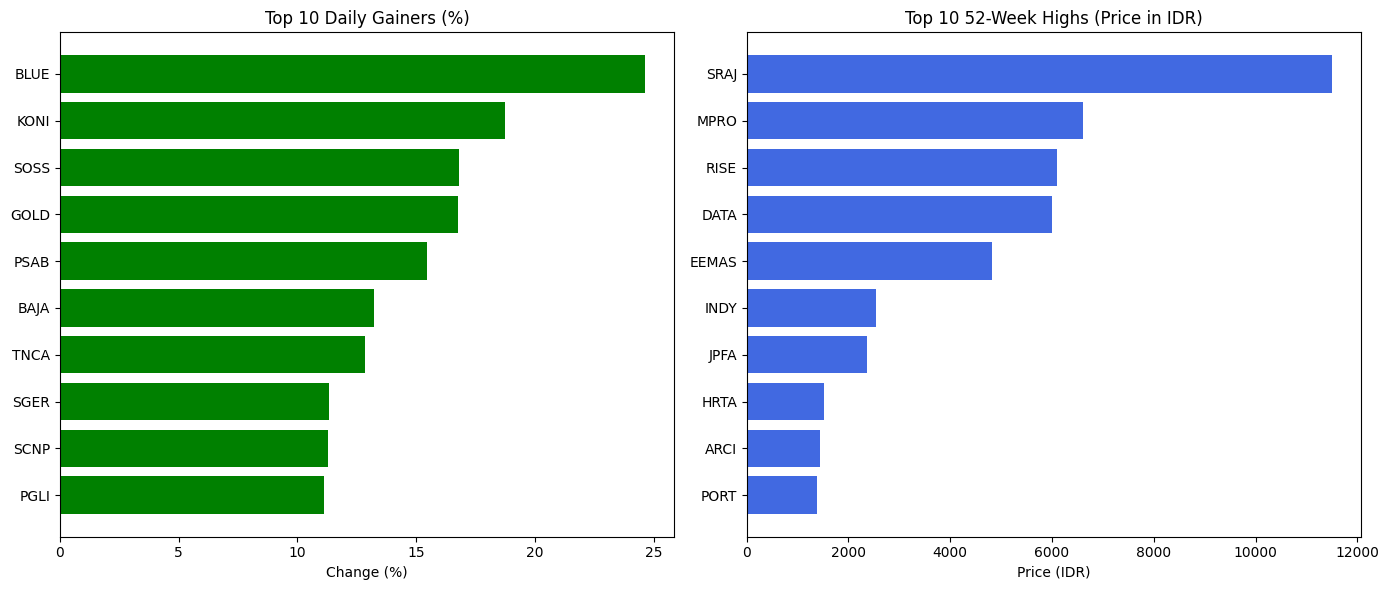

In [25]:
# Top 10 gainers by Change %
top_gainers = df_gainers_clean.nlargest(10, 'Change %')
# Top 10 52-week highs by Price
top_high = df_high_clean.nlargest(10, 'Price')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gainers
axes[0].barh(top_gainers['Ticker'], top_gainers['Change %'], color='green')
axes[0].set_title("Top 10 Daily Gainers (%)")
axes[0].invert_yaxis()
axes[0].set_xlabel("Change (%)")

# 52-week Highs
axes[1].barh(top_high['Ticker'], top_high['Price'], color='royalblue')
axes[1].set_title("Top 10 52-Week Highs (Price in IDR)")
axes[1].invert_yaxis()
axes[1].set_xlabel("Price (IDR)")

plt.tight_layout()
plt.show()


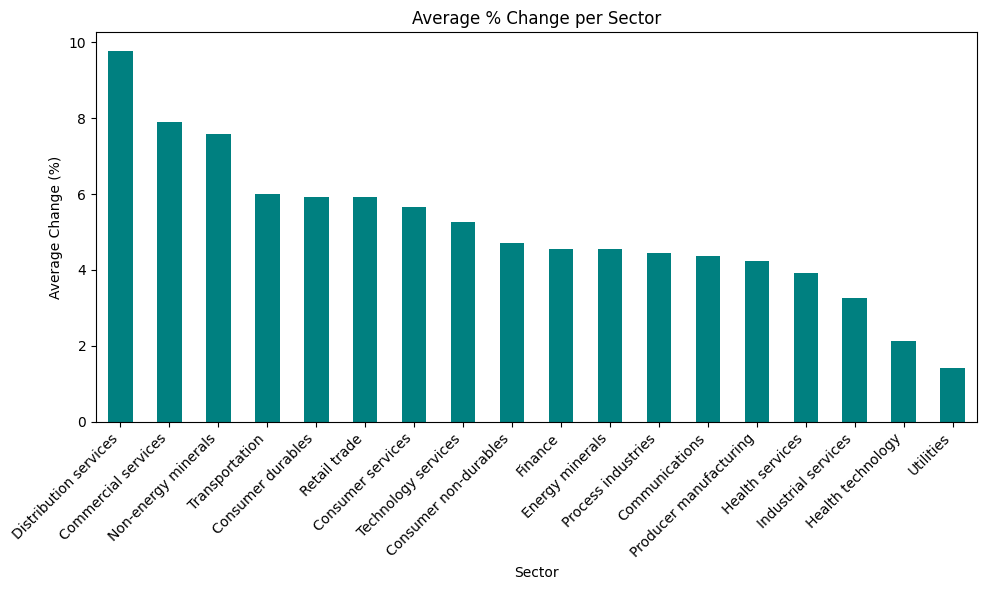

In [26]:
sector_performance = df_gainers_clean.groupby('Sector')['Change %'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sector_performance.plot(kind='bar', color='teal')
plt.title("Average % Change per Sector")
plt.ylabel("Average Change (%)")
plt.xlabel("Sector")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


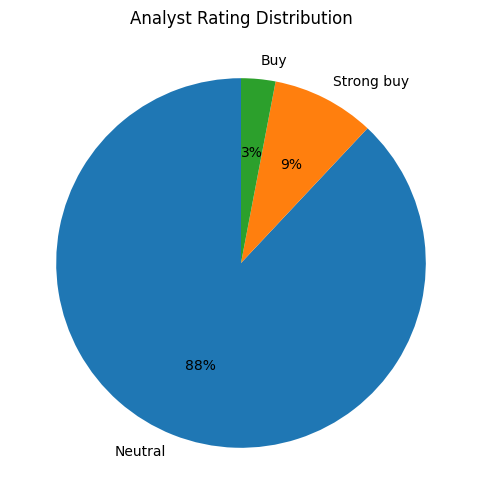

In [27]:
rating_counts = df_gainers_clean['Analyst Rating'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.0f%%', startangle=90)
plt.title("Analyst Rating Distribution")
plt.show()


In [28]:
# Get today's date for filenames 
today = datetime.now().strftime("%Y-%m-%d")

# Define filenames for each DataFrame
file_gainers_raw = f"df_gainers_raw_{today}.xlsx"
file_high_raw = f"df_high_raw_{today}.xlsx"
file_gainers_clean = f"df_gainers_clean_{today}.xlsx"
file_high_clean = f"df_high_clean_{today}.xlsx"

# Export each DataFrame to a separate Excel file
df_gainers.to_excel(file_gainers_raw, index=False)
df_high.to_excel(file_high_raw, index=False)
df_gainers_clean.to_excel(file_gainers_clean, index=False)
df_high_clean.to_excel(file_high_clean, index=False)

print("All DataFrames have been successfully exported as separate Excel files:")
print(f"- {file_gainers_raw}")
print(f"- {file_high_raw}")
print(f"- {file_gainers_clean}")
print(f"- {file_high_clean}")


All DataFrames have been successfully exported as separate Excel files:
- df_gainers_raw_2025-10-17.xlsx
- df_high_raw_2025-10-17.xlsx
- df_gainers_clean_2025-10-17.xlsx
- df_high_clean_2025-10-17.xlsx
